In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 9.0 MB/s eta 0:00:00


In [3]:
%cd /content/drive/MyDrive/competitions/signate_mufgcup2024/notebooks

/content/drive/MyDrive/competitions/signate_mufgcup2024/notebooks


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime
from tqdm import tqdm

In [5]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [6]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
DIR_MODEL = yml["SETTING"]["DIR_MODEL"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

In [7]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner, MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention
from src.util import Logger, Util

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [8]:
def load_feature(file_name):
    file_name = file_name + ".pkl"
    return pd.read_pickle(os.path.join(DIR_FEATURE, file_name))

# LSTM_台数

In [76]:
df_main_lstm_bikes = load_feature("df_key")
df_main_lstm_bikes = pd.merge(df_main_lstm_bikes, load_feature("df_predict_add_valid_flag"), on=["station_id","datetime"], how="left")
df_main_lstm_bikes = pd.merge(df_main_lstm_bikes, load_feature("df_bikes_available_fillna"), on=["station_id","datetime"], how="left")
df_main_lstm_bikes = pd.merge(df_main_lstm_bikes, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lstm_bikes = pd.merge(df_main_lstm_bikes, load_feature("df_datetime_atr"), on=["datetime"], how="left")

In [77]:
df_main_lstm_bikes.head()

,station_id,datetime,predict,bikes_available,lat,long,dock_count,installation_date,station_id_feat,installation_year,...,city_city3,city_city4,city_city5,datetime_feat,year,month,day,hour,weekday,holiday
0,0,2013-09-01 00:00:00,0,11.0,37.32973,-121.90178,27,20130806,0,2013,...,0,0,0,20130901,2013,9,1,0,6,1
1,0,2013-09-01 01:00:00,0,11.0,37.32973,-121.90178,27,20130806,0,2013,...,0,0,0,20130901,2013,9,1,1,6,1
2,0,2013-09-01 02:00:00,0,11.0,37.32973,-121.90178,27,20130806,0,2013,...,0,0,0,20130901,2013,9,1,2,6,1
3,0,2013-09-01 03:00:00,0,11.0,37.32973,-121.90178,27,20130806,0,2013,...,0,0,0,20130901,2013,9,1,3,6,1
4,0,2013-09-01 04:00:00,0,11.0,37.32973,-121.90178,27,20130806,0,2013,...,0,0,0,20130901,2013,9,1,4,6,1


In [25]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [17]:
# loggerの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

run_name = get_run_name(model_type="lstm_mult")
# run_name = 'lstm_mult_202410132245'
run_name

'lstm_mult_202410200122'

In [31]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 48,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 50,
    "learning_rate": 0.01,
    "weight_decay": 1e-5,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [32]:
memo = "LSTMのマルチステップ予測bikes seq_length=48,datetime_atrを追加"
timeseries_runner = TimeseriesModelRunner(run_name,
                                          model_LSTM_mult,
                                          model_params,
                                          df_main_lstm_bikes,
                                          run_setting,
                                          cv_setting,
                                          logger,
                                          memo)

In [33]:
timeseries_runner.run_train_cv()

[2024-10-20 01:35:45] - lstm_mult_202410200122 - start training cv
INFO:../logs/general:[2024-10-20 01:35:45] - lstm_mult_202410200122 - start training cv
[2024-10-20 01:35:45] - lstm_mult_202410200122 fold 2014-09-01 - start training
INFO:../logs/general:[2024-10-20 01:35:45] - lstm_mult_202410200122 fold 2014-09-01 - start training


(24506, 48, 8)
cuda
Epoch [1/50], Loss: 0.0659
Epoch [2/50], Loss: 0.0618
Epoch [3/50], Loss: 0.0583
Epoch [4/50], Loss: 0.0612
Epoch [5/50], Loss: 0.0603
Epoch [6/50], Loss: 0.0575
Epoch [7/50], Loss: 0.0542
Epoch [8/50], Loss: 0.0661
Epoch [9/50], Loss: 0.0499
Epoch [10/50], Loss: 0.0546
Epoch [11/50], Loss: 0.0564
Epoch [12/50], Loss: 0.0513
Epoch [13/50], Loss: 0.0574
Epoch [14/50], Loss: 0.0506
Epoch [15/50], Loss: 0.0618
Epoch [16/50], Loss: 0.0571
Epoch [17/50], Loss: 0.0527
Epoch [18/50], Loss: 0.0608
Epoch [19/50], Loss: 0.0530
Epoch [20/50], Loss: 0.0585
Epoch [21/50], Loss: 0.0563
Epoch [22/50], Loss: 0.0538
Epoch [23/50], Loss: 0.0501
Epoch [24/50], Loss: 0.0612
Epoch [25/50], Loss: 0.0554
Epoch [26/50], Loss: 0.0511
Epoch [27/50], Loss: 0.0621
Epoch [28/50], Loss: 0.0478
Epoch [29/50], Loss: 0.0487
Epoch [30/50], Loss: 0.0504
Epoch [31/50], Loss: 0.0501
Epoch [32/50], Loss: 0.0516
Epoch [33/50], Loss: 0.0580
Epoch [34/50], Loss: 0.0540
Epoch [35/50], Loss: 0.0521
Epoch [36

[2024-10-20 01:36:59] - lstm_mult_202410200122 fold 2014-09-01 - end training
INFO:../logs/general:[2024-10-20 01:36:59] - lstm_mult_202410200122 fold 2014-09-01 - end training
[2024-10-20 01:36:59] - lstm_mult_202410200122 fold 2014-10-01 - start training
INFO:../logs/general:[2024-10-20 01:36:59] - lstm_mult_202410200122 fold 2014-10-01 - start training


Epoch [50/50], Loss: 0.0486
(24926, 48, 8)
cuda
Epoch [1/50], Loss: 0.0539
Epoch [2/50], Loss: 0.0727
Epoch [3/50], Loss: 0.0617
Epoch [4/50], Loss: 0.0454
Epoch [5/50], Loss: 0.0528
Epoch [6/50], Loss: 0.0755
Epoch [7/50], Loss: 0.0530
Epoch [8/50], Loss: 0.0637
Epoch [9/50], Loss: 0.0582
Epoch [10/50], Loss: 0.0543
Epoch [11/50], Loss: 0.0588
Epoch [12/50], Loss: 0.0585
Epoch [13/50], Loss: 0.0672
Epoch [14/50], Loss: 0.0610
Epoch [15/50], Loss: 0.0593
Epoch [16/50], Loss: 0.0541
Epoch [17/50], Loss: 0.0442
Epoch [18/50], Loss: 0.0463
Epoch [19/50], Loss: 0.0609
Epoch [20/50], Loss: 0.0580
Epoch [21/50], Loss: 0.0563
Epoch [22/50], Loss: 0.0571
Epoch [23/50], Loss: 0.0592
Epoch [24/50], Loss: 0.0587
Epoch [25/50], Loss: 0.0620
Epoch [26/50], Loss: 0.0531
Epoch [27/50], Loss: 0.0571
Epoch [28/50], Loss: 0.0473
Epoch [29/50], Loss: 0.0537
Epoch [30/50], Loss: 0.0505
Epoch [31/50], Loss: 0.0496
Epoch [32/50], Loss: 0.0606
Epoch [33/50], Loss: 0.0483
Epoch [34/50], Loss: 0.0468
Epoch [35

[2024-10-20 01:38:15] - lstm_mult_202410200122 fold 2014-10-01 - end training
INFO:../logs/general:[2024-10-20 01:38:15] - lstm_mult_202410200122 fold 2014-10-01 - end training
[2024-10-20 01:38:15] - lstm_mult_202410200122 fold 2014-11-01 - start training
INFO:../logs/general:[2024-10-20 01:38:15] - lstm_mult_202410200122 fold 2014-11-01 - start training


...

Epoch [50/50], Loss: 0.0479
(28356, 48, 8)
cuda
Epoch [1/50], Loss: 0.0717
Epoch [2/50], Loss: 0.0393
Epoch [3/50], Loss: 0.0372
Epoch [4/50], Loss: 0.0448
Epoch [5/50], Loss: 0.0599
Epoch [6/50], Loss: 0.0703
Epoch [7/50], Loss: 0.0473
Epoch [8/50], Loss: 0.0340
Epoch [9/50], Loss: 0.0655
Epoch [10/50], Loss: 0.0824
Epoch [11/50], Loss: 0.0548
Epoch [12/50], Loss: 0.0406
Epoch [13/50], Loss: 0.0257
Epoch [14/50], Loss: 0.0889
Epoch [15/50], Loss: 0.0704
Epoch [16/50], Loss: 0.0314
Epoch [17/50], Loss: 0.0485
Epoch [18/50], Loss: 0.0525
Epoch [19/50], Loss: 0.0638
Epoch [20/50], Loss: 0.0704
Epoch [21/50], Loss: 0.0293
Epoch [22/50], Loss: 0.0490
Epoch [23/50], Loss: 0.0699
Epoch [24/50], Loss: 0.0579
Epoch [25/50], Loss: 0.0461
Epoch [26/50], Loss: 0.0541
Epoch [27/50], Loss: 0.0469
Epoch [28/50], Loss: 0.0298
Epoch [29/50], Loss: 0.0278
Epoch [30/50], Loss: 0.0671
Epoch [31/50], Loss: 0.0584
Epoch [32/50], Loss: 0.0343
Epoch [33/50], Loss: 0.0606
Epoch [34/50], Loss: 0.0727
Epoch [35

[2024-10-20 01:51:04] - lstm_mult_202410200122 fold 2015-07-01 - end training
INFO:../logs/general:[2024-10-20 01:51:04] - lstm_mult_202410200122 fold 2015-07-01 - end training
[2024-10-20 01:51:04] - lstm_mult_202410200122 fold 2015-08-01 - start training
INFO:../logs/general:[2024-10-20 01:51:04] - lstm_mult_202410200122 fold 2015-08-01 - start training


Epoch [50/50], Loss: 0.0442
(28706, 48, 8)
cuda
Epoch [1/50], Loss: 0.0520
Epoch [2/50], Loss: 0.0589
Epoch [3/50], Loss: 0.0748
Epoch [4/50], Loss: 0.0568
Epoch [5/50], Loss: 0.0537
Epoch [6/50], Loss: 0.0601
Epoch [7/50], Loss: 0.0613
Epoch [8/50], Loss: 0.0507
Epoch [9/50], Loss: 0.0547
Epoch [10/50], Loss: 0.0557
Epoch [11/50], Loss: 0.0559
Epoch [12/50], Loss: 0.0668
Epoch [13/50], Loss: 0.0533
Epoch [14/50], Loss: 0.0578
Epoch [15/50], Loss: 0.0535
Epoch [16/50], Loss: 0.0581
Epoch [17/50], Loss: 0.0516
Epoch [18/50], Loss: 0.0570
Epoch [19/50], Loss: 0.0677
Epoch [20/50], Loss: 0.0596
Epoch [21/50], Loss: 0.0592
Epoch [22/50], Loss: 0.0435
Epoch [23/50], Loss: 0.0574
Epoch [24/50], Loss: 0.0626
Epoch [25/50], Loss: 0.0433
Epoch [26/50], Loss: 0.0469
Epoch [27/50], Loss: 0.0564
Epoch [28/50], Loss: 0.0537
Epoch [29/50], Loss: 0.0504
Epoch [30/50], Loss: 0.0491
Epoch [31/50], Loss: 0.0590
Epoch [32/50], Loss: 0.0502
Epoch [33/50], Loss: 0.0475
Epoch [34/50], Loss: 0.0581
Epoch [35

[2024-10-20 01:52:37] - lstm_mult_202410200122 fold 2015-08-01 - end training
INFO:../logs/general:[2024-10-20 01:52:37] - lstm_mult_202410200122 fold 2015-08-01 - end training
[2024-10-20 01:52:37] - lstm_mult_202410200122 - end training cv
INFO:../logs/general:[2024-10-20 01:52:37] - lstm_mult_202410200122 - end training cv


Epoch [50/50], Loss: 0.0472


In [34]:
timeseries_runner.run_metric_cv()

[2024-10-20 01:52:37] - lstm_mult_202410200122 - start metric cv
INFO:../logs/general:[2024-10-20 01:52:37] - lstm_mult_202410200122 - start metric cv
100%|██████████| 12/12 [00:46<00:00,  3.86s/it]
memo: LSTMのマルチステップ予測bikes seq_length=48,datetime_atrを追加
INFO:../logs/result:memo: LSTMのマルチステップ予測bikes seq_length=48,datetime_atrを追加
run_name:lstm_mult_202410200122	score_mean:1.5836189449304658	score0:1.6048965623713858	score1:1.7877218950979459	score2:1.5389014193148558	score3:1.4784181289717278	score4:1.625275749523447	score5:1.3986984033762297	score6:1.5682445295516008	score7:1.5345092502162323	score8:1.5189614268047893	score9:1.6675645822006038	score10:1.7087940756874795	score11:1.5714413160492915
INFO:../logs/result:run_name:lstm_mult_202410200122	score_mean:1.5836189449304658	score0:1.6048965623713858	score1:1.7877218950979459	score2:1.5389014193148558	score3:1.4784181289717278	score4:1.625275749523447	score5:1.3986984033762297	score6:1.5682445295516008	score7:1.5345092502162323	score

In [35]:
timeseries_runner.run_predict_cv()

[2024-10-20 01:53:24] - lstm_mult_202410200122 - start prediction cv
INFO:../logs/general:[2024-10-20 01:53:24] - lstm_mult_202410200122 - start prediction cv
100%|██████████| 12/12 [01:11<00:00,  6.00s/it]
[2024-10-20 01:54:36] - output predict : ../models/lstm_mult_202410200122/te_pred.pkl
INFO:../logs/general:[2024-10-20 01:54:36] - output predict : ../models/lstm_mult_202410200122/te_pred.pkl
[2024-10-20 01:54:36] - lstm_mult_202410200122 - end prediction cv
INFO:../logs/general:[2024-10-20 01:54:36] - lstm_mult_202410200122 - end prediction cv


In [37]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_FEATURE, "df_target_all.pkl"))[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTMのマルチステップ予測bikes seq_length=48,datetime_atrを追加


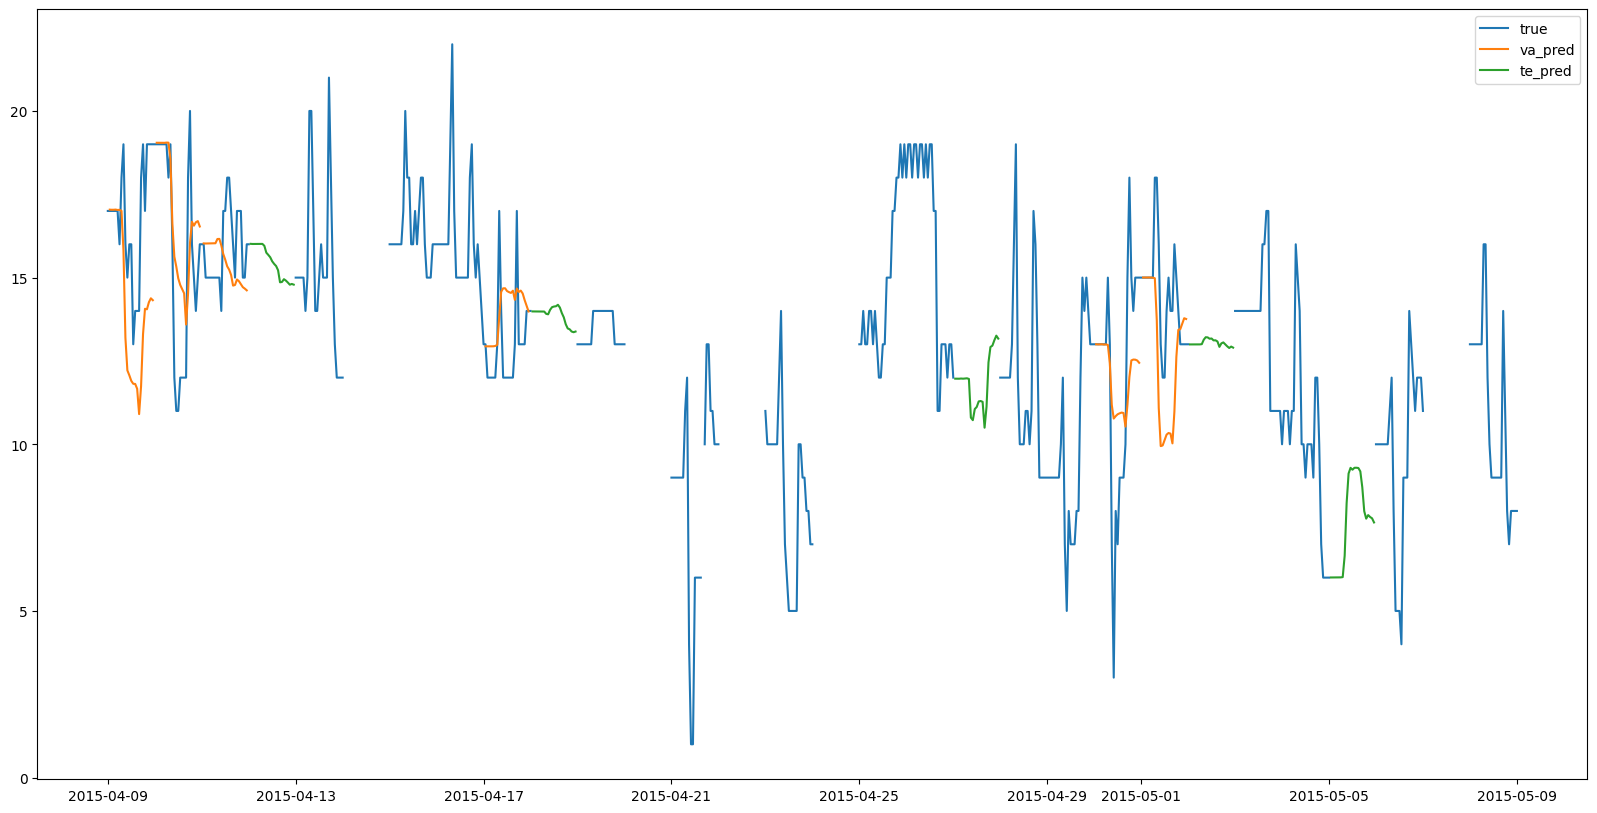

In [39]:
# 元の目的関数が欠損している部分（）
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTMのマルチステップ予測 学習率0.001 epoch5


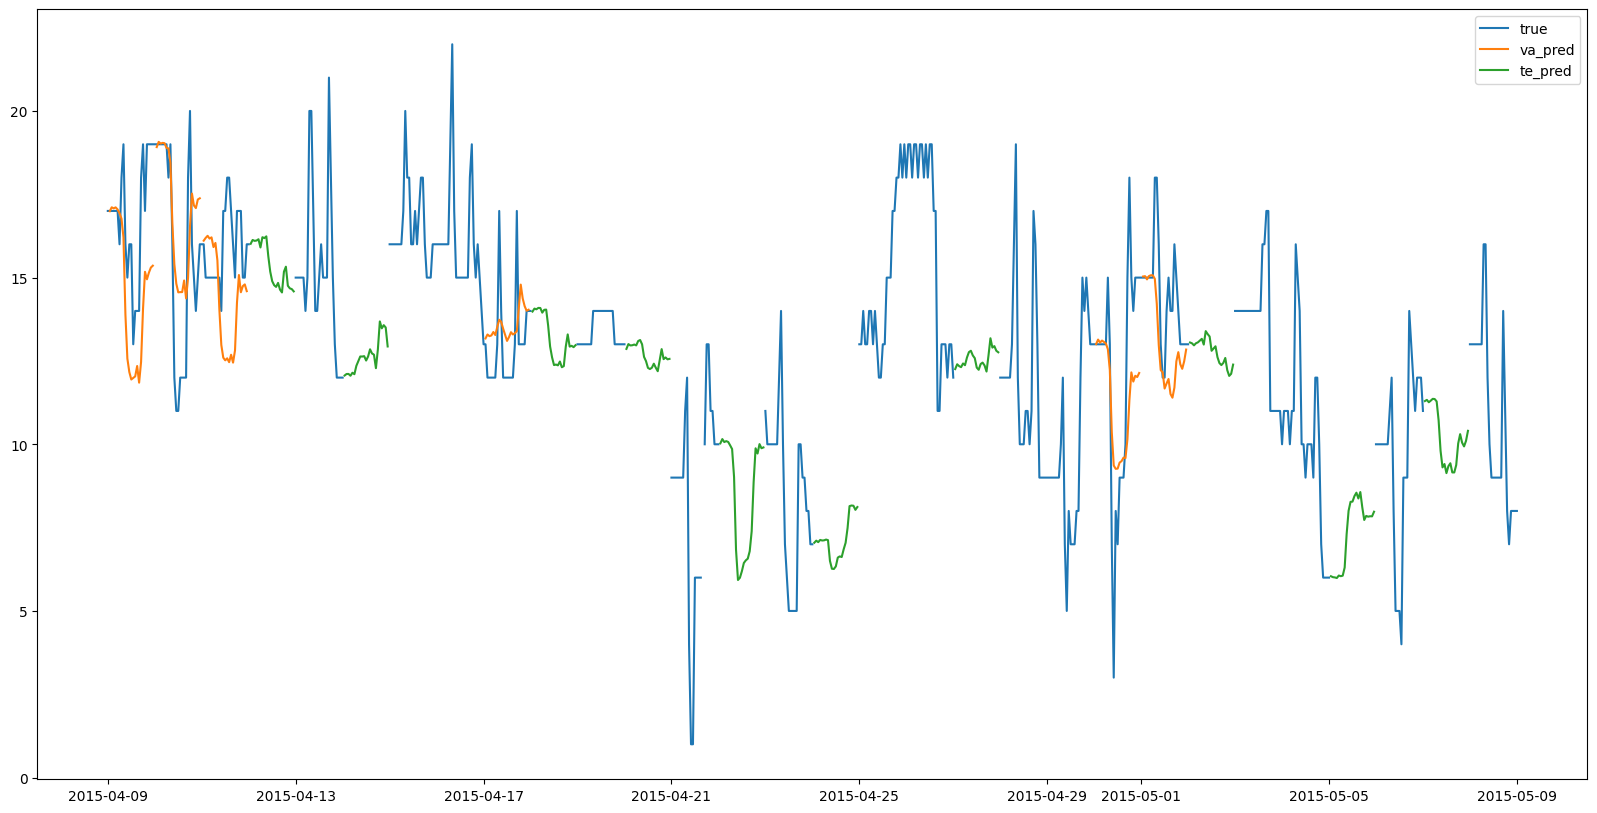

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [40]:
# 学習データ数の推移
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

2014-08-01 00:00:00 (22336, 48, 8)
2014-09-01 00:00:00 (24506, 48, 8)
2014-10-01 00:00:00 (24926, 48, 8)
2014-11-01 00:00:00 (25346, 48, 8)
2014-12-01 00:00:00 (25836, 48, 8)
2015-01-01 00:00:00 (26186, 48, 8)
2015-02-01 00:00:00 (26676, 48, 8)
2015-03-01 00:00:00 (26886, 48, 8)
2015-04-01 00:00:00 (27236, 48, 8)
2015-05-01 00:00:00 (27586, 48, 8)
2015-06-01 00:00:00 (28076, 48, 8)
2015-07-01 00:00:00 (28356, 48, 8)
2015-08-01 00:00:00 (28706, 48, 8)


# LSTM_需要

In [9]:
df_main_demand_lstm = df_key.copy()
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_predict_add_valid_flag, on=["station_id","datetime"], how="left")
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_demand_cumsum, on=["station_id","datetime"], how="left")
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_supply_cumsum, on=["station_id","datetime"], how="left")
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_weekday, on=["datetime"], how="left")

NameError: name 'df_key' is not defined

In [59]:
df_main_demand_lstm.to_pickle(os.path.join(DIR_INTERIM, "df_main_demand_lstm.pkl"))

In [11]:
df_main_demand_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_demand_lstm.pkl"))

In [12]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [13]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lstm_mult_demand")
# run_name = 'lstm_demand_202410142258'
run_name

'lstm_mult_demand_202410191342'

In [14]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(upper=0)

    return df_pred

model_params_lstm_demand = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "seq_length": 96,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 128,
    "num_epochs": 20,
    "learning_rate": 0.01,
    "weight_decay": 1e-5,
}
run_setting_lstm_demand = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lstm_demand = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [15]:
memo = "LSTM demand_cumsum supply_cumsumを追加"
timeseries_runner = TimeseriesModelRunner(
    run_name,
    model_LSTM_mult,
    model_params_lstm_demand,
    df_main_demand_lstm,
    run_setting_lstm_demand,
    cv_setting_lstm_demand,
    logger,
    memo)

In [16]:
timeseries_runner.run_train_cv()

[2024-10-19 13:42:48] - lstm_mult_demand_202410191342 - start training cv
INFO:../logs/general:[2024-10-19 13:42:48] - lstm_mult_demand_202410191342 - start training cv
[2024-10-19 13:42:49] - lstm_mult_demand_202410191342 fold 2014-09-01 - start training
INFO:../logs/general:[2024-10-19 13:42:49] - lstm_mult_demand_202410191342 fold 2014-09-01 - start training


(25270, 96, 3)
cuda


KeyboardInterrupt: 

In [69]:
timeseries_runner.run_metric_cv()

[2024-10-19 03:38:21] - lstm_mult_demand_202410190321 - start metric cv
INFO:../logs/general:[2024-10-19 03:38:21] - lstm_mult_demand_202410190321 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

hello
hello
hello
hello
hello
hello


  8%|▊         | 1/12 [00:02<00:30,  2.77s/it]

hello
hello
hello
hello
hello
hello


 17%|█▋        | 2/12 [00:05<00:28,  2.84s/it]

...

 83%|████████▎ | 10/12 [00:30<00:06,  3.15s/it]

hello
hello
hello
hello
hello


 92%|█████████▏| 11/12 [00:33<00:03,  3.18s/it]

hello
hello
hello
hello
hello


100%|██████████| 12/12 [00:37<00:00,  3.10s/it]
memo: LSTM demand_cumsum supply_cumsumを追加
INFO:../logs/result:memo: LSTM demand_cumsum supply_cumsumを追加
run_name:lstm_mult_demand_202410190321	score_mean:2.149402200804975	score0:2.2241234232611786	score1:2.1515772011339296	score2:2.7827455552732827	score3:1.5104594123289452	score4:2.253529555160807	score5:2.488832307824437	score6:2.3047974284835484	score7:1.7592984673695535	score8:1.8003446548198745	score9:2.741083004108127	score10:2.0983640870100224	score11:1.6776713128859952
INFO:../logs/result:run_name:lstm_mult_demand_202410190321	score_mean:2.149402200804975	score0:2.2241234232611786	score1:2.1515772011339296	score2:2.7827455552732827	score3:1.5104594123289452	score4:2.253529555160807	score5:2.488832307824437	score6:2.3047974284835484	score7:1.7592984673695535	score8:1.8003446548198745	score9:2.741083004108127	score10:2.0983640870100224	score11:1.6776713128859952
mean: 2.149402200804975, std: 0.3888450687068449
INFO:../logs/result:m

In [70]:
timeseries_runner.run_predict_cv()

[2024-10-19 03:38:58] - lstm_mult_demand_202410190321 - start prediction cv
INFO:../logs/general:[2024-10-19 03:38:58] - lstm_mult_demand_202410190321 - start prediction cv
  0%|          | 0/12 [00:00<?, ?it/s]

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello


  8%|▊         | 1/12 [00:03<00:40,  3.69s/it]

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello


 17%|█▋        | 2/12 [00:07<00:38,  3.80s/it]

...

 83%|████████▎ | 10/12 [00:45<00:09,  4.92s/it]

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello


 92%|█████████▏| 11/12 [00:50<00:05,  5.13s/it]

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello


100%|██████████| 12/12 [00:56<00:00,  4.71s/it]
[2024-10-19 03:39:54] - output predict : ../models/lstm_mult_demand_202410190321/te_pred.pkl
INFO:../logs/general:[2024-10-19 03:39:54] - output predict : ../models/lstm_mult_demand_202410190321/te_pred.pkl
[2024-10-19 03:39:54] - lstm_mult_demand_202410190321 - end prediction cv
INFO:../logs/general:[2024-10-19 03:39:54] - lstm_mult_demand_202410190321 - end prediction cv


In [71]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_demand_lstm[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTM demand_cumsum supply_cumsumを追加


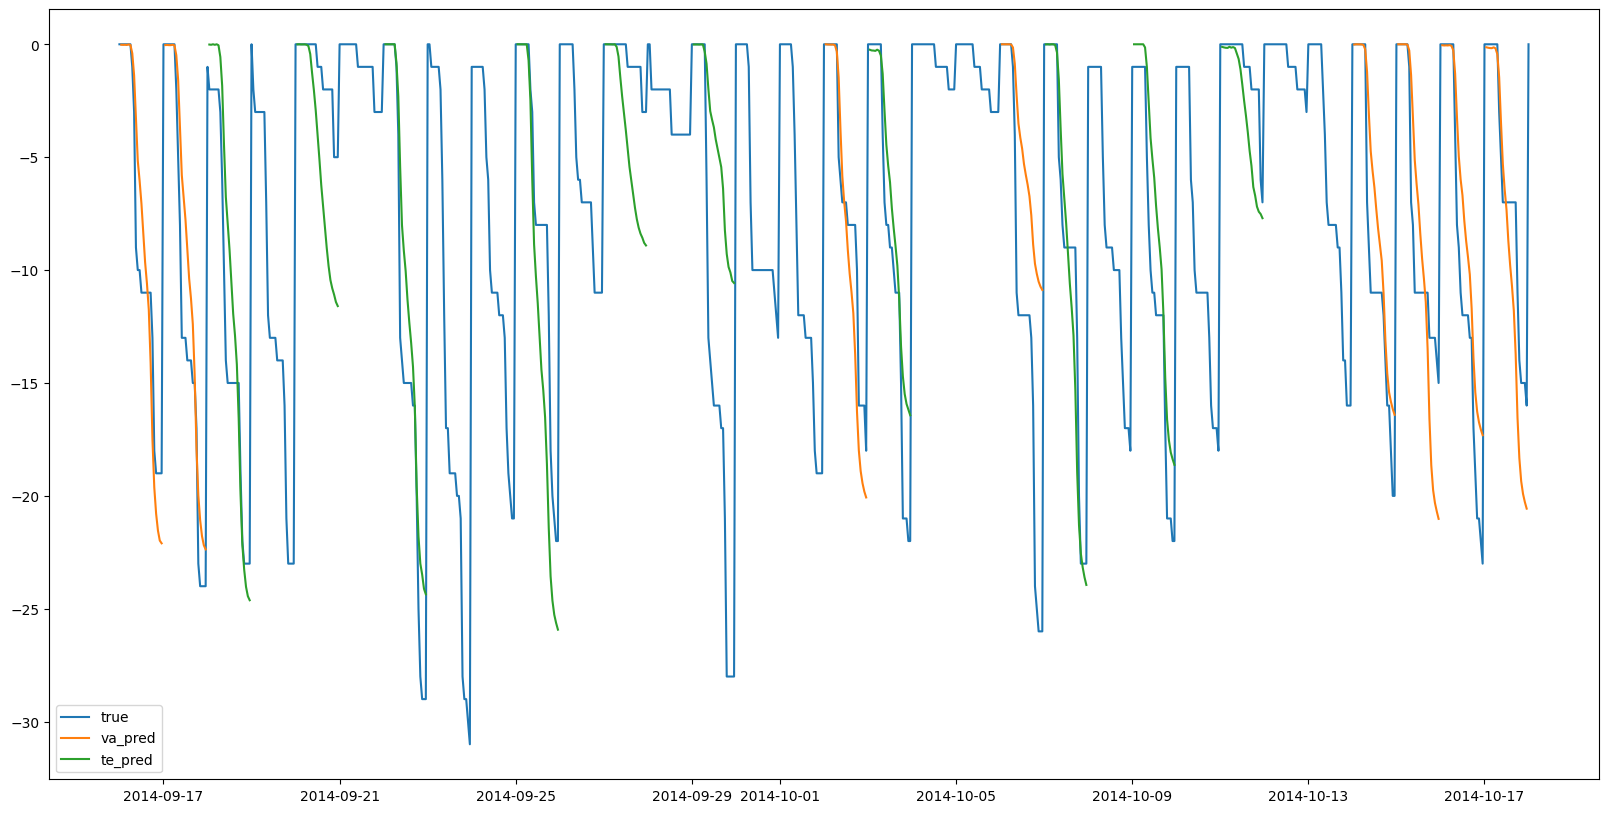

In [72]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTM demand_cumsum seq_length=96


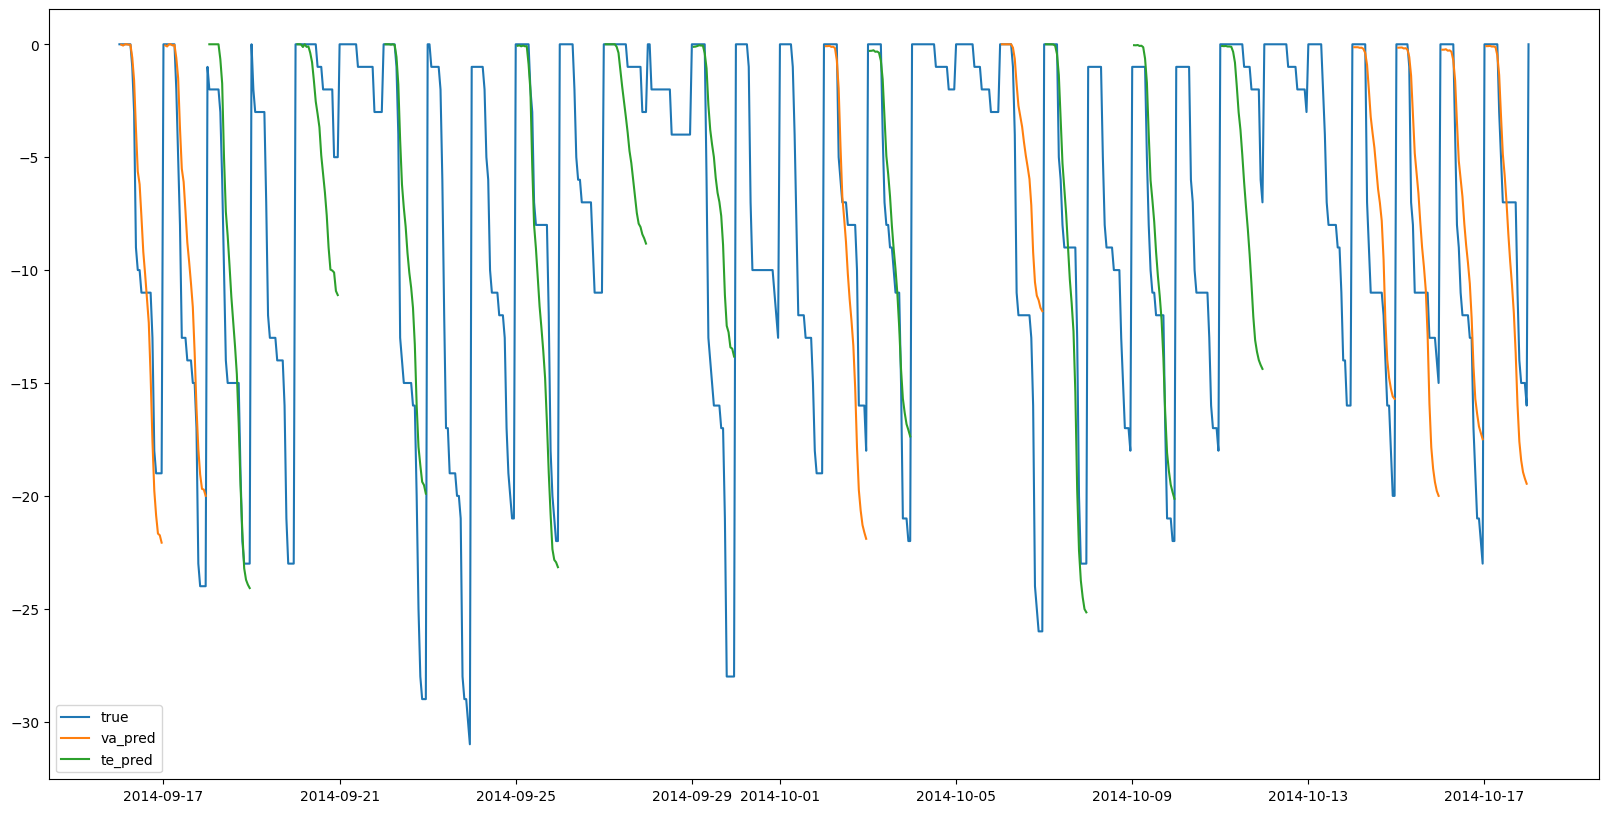

In [184]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_供給

In [73]:
df_main_supply_lstm = df_key.copy()
df_main_supply_lstm = pd.merge(df_main_supply_lstm, df_predict_add_valid_flag, on=["station_id","datetime"], how="left")
df_main_supply_lstm = pd.merge(df_main_supply_lstm, df_supply_cumsum, on=["station_id","datetime"], how="left")
df_main_supply_lstm = pd.merge(df_main_supply_lstm, df_demand_cumsum, on=["station_id","datetime"], how="left")
df_main_supply_lstm = pd.merge(df_main_supply_lstm, df_weekday, on=["datetime"], how="left")

In [74]:
df_main_supply_lstm.to_pickle(os.path.join(DIR_INTERIM, "df_main_supply_lstm.pkl"))

In [75]:
df_main_supply_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_supply_lstm.pkl"))

In [82]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [76]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

# run_nameの設定
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

run_name = get_run_name(model_type="lstm_mult_supply")
# run_name = 'lstm_demand_202410142258'
run_name

'lstm_mult_supply_202410190339'

In [77]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)

    return df_pred

model_params_lstm_supply = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "seq_length": 96,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 128,
    "num_epochs": 20,
    "learning_rate": 0.01,
    "weight_decay": 1e-5,
}
run_setting_lstm_supply = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lstm_supply = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [83]:
memo = "LSTM supply_cumsum demand_cumsum追加"
timeseries_runner = TimeseriesModelRunner(
    run_name,
    model_LSTM_mult,
    model_params_lstm_supply,
    df_main_supply_lstm,
    run_setting_lstm_supply,
    cv_setting_lstm_supply,
    logger,
    memo,
)

In [79]:
timeseries_runner.run_train_cv()

[2024-10-19 03:39:59] - lstm_mult_supply_202410190339 - start training cv
INFO:../logs/general:[2024-10-19 03:39:59] - lstm_mult_supply_202410190339 - start training cv
[2024-10-19 03:39:59] - lstm_mult_supply_202410190339 fold 2014-09-01 - start training
INFO:../logs/general:[2024-10-19 03:39:59] - lstm_mult_supply_202410190339 fold 2014-09-01 - start training


(25270, 96, 3)
cuda
Epoch [1/20], Loss: 0.0150
Epoch [2/20], Loss: 0.0159
Epoch [3/20], Loss: 0.0113
Epoch [4/20], Loss: 0.0146
Epoch [5/20], Loss: 0.0133
Epoch [6/20], Loss: 0.0088
Epoch [7/20], Loss: 0.0123
Epoch [8/20], Loss: 0.0100
Epoch [9/20], Loss: 0.0136
Epoch [10/20], Loss: 0.0106
Epoch [11/20], Loss: 0.0109
Epoch [12/20], Loss: 0.0114
Epoch [13/20], Loss: 0.0121
Epoch [14/20], Loss: 0.0123
Epoch [15/20], Loss: 0.0152
Epoch [16/20], Loss: 0.0140
Epoch [17/20], Loss: 0.0126
Epoch [18/20], Loss: 0.0110
Epoch [19/20], Loss: 0.0092
Epoch [20/20], Loss: 0.0090


[2024-10-19 03:40:47] - lstm_mult_supply_202410190339 fold 2014-09-01 - end training
INFO:../logs/general:[2024-10-19 03:40:47] - lstm_mult_supply_202410190339 fold 2014-09-01 - end training
[2024-10-19 03:40:47] - lstm_mult_supply_202410190339 fold 2014-10-01 - start training
INFO:../logs/general:[2024-10-19 03:40:47] - lstm_mult_supply_202410190339 fold 2014-10-01 - start training


(27370, 96, 3)
cuda
Epoch [1/20], Loss: 0.0147
Epoch [2/20], Loss: 0.0121
Epoch [3/20], Loss: 0.0102
Epoch [4/20], Loss: 0.0105
Epoch [5/20], Loss: 0.0079
Epoch [6/20], Loss: 0.0170
Epoch [7/20], Loss: 0.0142
Epoch [8/20], Loss: 0.0130
Epoch [9/20], Loss: 0.0127
Epoch [10/20], Loss: 0.0111
Epoch [11/20], Loss: 0.0113
Epoch [12/20], Loss: 0.0126
Epoch [13/20], Loss: 0.0124
Epoch [14/20], Loss: 0.0092
Epoch [15/20], Loss: 0.0143
Epoch [16/20], Loss: 0.0085
Epoch [17/20], Loss: 0.0114
Epoch [18/20], Loss: 0.0126
Epoch [19/20], Loss: 0.0136


[2024-10-19 03:41:39] - lstm_mult_supply_202410190339 fold 2014-10-01 - end training
INFO:../logs/general:[2024-10-19 03:41:39] - lstm_mult_supply_202410190339 fold 2014-10-01 - end training
[2024-10-19 03:41:39] - lstm_mult_supply_202410190339 fold 2014-11-01 - start training
INFO:../logs/general:[2024-10-19 03:41:39] - lstm_mult_supply_202410190339 fold 2014-11-01 - start training


...

[2024-10-19 03:51:02] - lstm_mult_supply_202410190339 fold 2015-06-01 - end training
INFO:../logs/general:[2024-10-19 03:51:02] - lstm_mult_supply_202410190339 fold 2015-06-01 - end training
[2024-10-19 03:51:02] - lstm_mult_supply_202410190339 fold 2015-07-01 - start training
INFO:../logs/general:[2024-10-19 03:51:02] - lstm_mult_supply_202410190339 fold 2015-07-01 - start training


(46480, 96, 3)
cuda
Epoch [1/20], Loss: 0.0128
Epoch [2/20], Loss: 0.0086
Epoch [3/20], Loss: 0.0119
Epoch [4/20], Loss: 0.0099
Epoch [5/20], Loss: 0.0119
Epoch [6/20], Loss: 0.0076
Epoch [7/20], Loss: 0.0086
Epoch [8/20], Loss: 0.0045
Epoch [9/20], Loss: 0.0045
Epoch [10/20], Loss: 0.0204
Epoch [11/20], Loss: 0.0179
Epoch [12/20], Loss: 0.0064
Epoch [13/20], Loss: 0.0054
Epoch [14/20], Loss: 0.0088
Epoch [15/20], Loss: 0.0109
Epoch [16/20], Loss: 0.0084
Epoch [17/20], Loss: 0.0129
Epoch [18/20], Loss: 0.0137
Epoch [19/20], Loss: 0.0105
Epoch [20/20], Loss: 0.0086


[2024-10-19 03:52:31] - lstm_mult_supply_202410190339 fold 2015-07-01 - end training
INFO:../logs/general:[2024-10-19 03:52:31] - lstm_mult_supply_202410190339 fold 2015-07-01 - end training
[2024-10-19 03:52:31] - lstm_mult_supply_202410190339 fold 2015-08-01 - start training
INFO:../logs/general:[2024-10-19 03:52:31] - lstm_mult_supply_202410190339 fold 2015-08-01 - start training


(48650, 96, 3)
cuda
Epoch [1/20], Loss: 0.0091
Epoch [2/20], Loss: 0.0092
Epoch [3/20], Loss: 0.0192
Epoch [4/20], Loss: 0.0081
Epoch [5/20], Loss: 0.0116
Epoch [6/20], Loss: 0.0098
Epoch [7/20], Loss: 0.0098
Epoch [8/20], Loss: 0.0079
Epoch [9/20], Loss: 0.0102
Epoch [10/20], Loss: 0.0089
Epoch [11/20], Loss: 0.0112
Epoch [12/20], Loss: 0.0090
Epoch [13/20], Loss: 0.0122
Epoch [14/20], Loss: 0.0075
Epoch [15/20], Loss: 0.0086
Epoch [16/20], Loss: 0.0104
Epoch [17/20], Loss: 0.0056
Epoch [18/20], Loss: 0.0090
Epoch [19/20], Loss: 0.0075
Epoch [20/20], Loss: 0.0108


[2024-10-19 03:54:04] - lstm_mult_supply_202410190339 fold 2015-08-01 - end training
INFO:../logs/general:[2024-10-19 03:54:04] - lstm_mult_supply_202410190339 fold 2015-08-01 - end training
[2024-10-19 03:54:04] - lstm_mult_supply_202410190339 - end training cv
INFO:../logs/general:[2024-10-19 03:54:04] - lstm_mult_supply_202410190339 - end training cv


In [84]:
timeseries_runner.run_metric_cv()

[2024-10-19 03:55:24] - lstm_mult_supply_202410190339 - start metric cv
INFO:../logs/general:[2024-10-19 03:55:24] - lstm_mult_supply_202410190339 - start metric cv
100%|██████████| 12/12 [00:37<00:00,  3.15s/it]
memo: LSTM supply_cumsum demand_cumsum追加
INFO:../logs/result:memo: LSTM supply_cumsum demand_cumsum追加
run_name:lstm_mult_supply_202410190339	score_mean:2.004497296196876	score0:2.453706487120792	score1:2.38032638738773	score2:2.7102720729140772	score3:1.5303648900306095	score4:2.201898182279977	score5:1.6433787758417	score6:2.0198066215063695	score7:1.6392948822159512	score8:1.7278992290041835	score9:2.1252368432069093	score10:1.9022304269348695	score11:1.719552755919342
INFO:../logs/result:run_name:lstm_mult_supply_202410190339	score_mean:2.004497296196876	score0:2.453706487120792	score1:2.38032638738773	score2:2.7102720729140772	score3:1.5303648900306095	score4:2.201898182279977	score5:1.6433787758417	score6:2.0198066215063695	score7:1.6392948822159512	score8:1.7278992290041

In [85]:
timeseries_runner.run_predict_cv()

[2024-10-19 03:56:02] - lstm_mult_supply_202410190339 - start prediction cv
INFO:../logs/general:[2024-10-19 03:56:02] - lstm_mult_supply_202410190339 - start prediction cv
100%|██████████| 12/12 [00:55<00:00,  4.63s/it]
[2024-10-19 03:56:58] - output predict : ../models/lstm_mult_supply_202410190339/te_pred.pkl
INFO:../logs/general:[2024-10-19 03:56:58] - output predict : ../models/lstm_mult_supply_202410190339/te_pred.pkl
[2024-10-19 03:56:58] - lstm_mult_supply_202410190339 - end prediction cv
INFO:../logs/general:[2024-10-19 03:56:58] - lstm_mult_supply_202410190339 - end prediction cv


In [86]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_supply_lstm[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTM supply_cumsum demand_cumsum追加


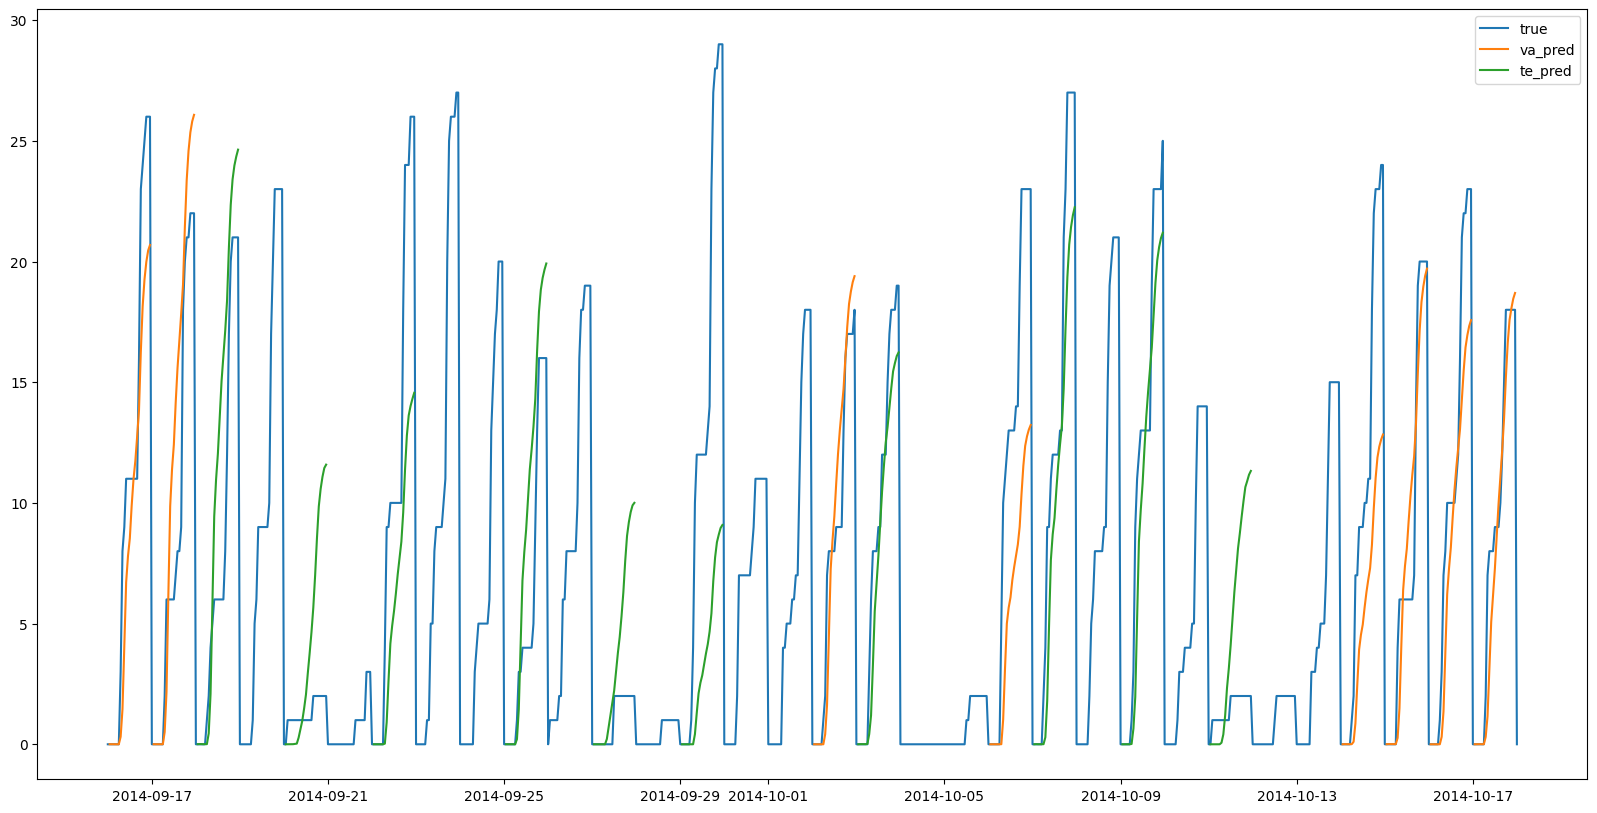

In [87]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTM supply_cumsum demand_cumsum追加


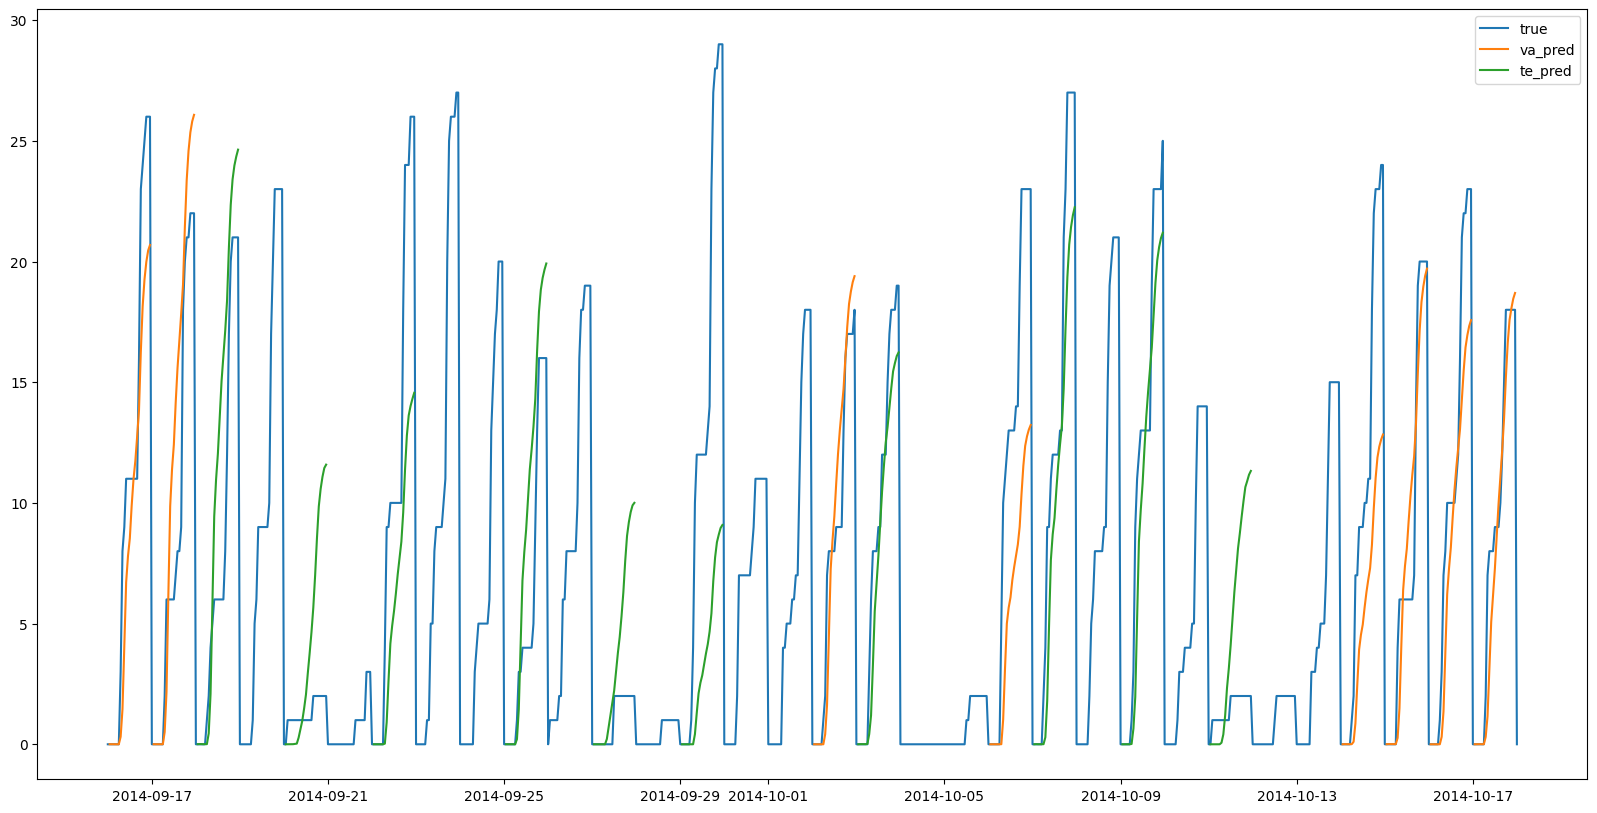

In [88]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_介入

In [89]:
df_main_intervention_lstm = df_key.copy()
df_main_intervention_lstm = pd.merge(df_main_intervention_lstm, df_predict_add_valid_flag, on=["station_id","datetime"], how="left")
df_main_intervention_lstm = pd.merge(df_main_intervention_lstm, df_intervention_cumsum_fillna, on=["station_id","datetime"], how="left")
df_main_intervention_lstm = pd.merge(df_main_intervention_lstm, df_demand_cumsum, on=["station_id","datetime"], how="left")
df_main_intervention_lstm = pd.merge(df_main_intervention_lstm, df_supply_cumsum, on=["station_id","datetime"], how="left")
df_main_intervention_lstm = pd.merge(df_main_intervention_lstm, df_weekday, on=["datetime"], how="left")

In [90]:
df_main_intervention_lstm.to_pickle(os.path.join(DIR_INTERIM, "df_main_intervention_lstm.pkl"))

In [8]:
df_main_intervention_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_intervention_lstm.pkl"))

In [44]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [41]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

# run_nameの設定
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

run_name = get_run_name(model_type="lstm_mult_intervention")
run_name = 'lstm_mult_intervention_202410190357'
run_name

'lstm_mult_intervention_202410190357'

In [42]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    return df_pred

model_params_lstm_intervention = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "seq_length": 48, # 48以上はpredict=1の欠損値処理が必要
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 20,
    "learning_rate": 0.01,
    "weight_decay": 1e-5,
}

run_setting_lstm_intervention = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}

cv_setting_lstm_intervention = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [45]:
memo = "LSTM intervention_cumsum seq_length=48"
timeseries_runner = TimeseriesModelRunner(
    run_name,
    model_LSTM_mult,
    model_params_lstm_intervention,
    df_main_intervention_lstm,
    run_setting_lstm_intervention,
    cv_setting_lstm_intervention,
    logger,
    memo,
)

In [35]:
timeseries_runner.run_train_cv()

[2024-10-19 05:19:34] - lstm_mult_intervention_202410190357 - start training cv
INFO:../logs/general:[2024-10-19 05:19:34] - lstm_mult_intervention_202410190357 - start training cv
[2024-10-19 05:19:34] - lstm_mult_intervention_202410190357 fold 2014-09-01 - start training
INFO:../logs/general:[2024-10-19 05:19:34] - lstm_mult_intervention_202410190357 fold 2014-09-01 - start training


(24506, 48, 4)
cuda
Epoch [1/20], Loss: 0.0160
Epoch [2/20], Loss: 0.0112
Epoch [3/20], Loss: 0.0151
Epoch [4/20], Loss: 0.0131
Epoch [5/20], Loss: 0.0158
Epoch [6/20], Loss: 0.0078
Epoch [7/20], Loss: 0.0099
Epoch [8/20], Loss: 0.0115
Epoch [9/20], Loss: 0.0061
Epoch [10/20], Loss: 0.0129
Epoch [11/20], Loss: 0.0102
Epoch [12/20], Loss: 0.0130
Epoch [13/20], Loss: 0.0123
Epoch [14/20], Loss: 0.0121
Epoch [15/20], Loss: 0.0094
Epoch [16/20], Loss: 0.0115
Epoch [17/20], Loss: 0.0107
Epoch [18/20], Loss: 0.0097
Epoch [19/20], Loss: 0.0125
Epoch [20/20], Loss: 0.0096


[2024-10-19 05:20:24] - lstm_mult_intervention_202410190357 fold 2014-09-01 - end training
INFO:../logs/general:[2024-10-19 05:20:24] - lstm_mult_intervention_202410190357 fold 2014-09-01 - end training
[2024-10-19 05:20:24] - lstm_mult_intervention_202410190357 fold 2014-10-01 - start training
INFO:../logs/general:[2024-10-19 05:20:24] - lstm_mult_intervention_202410190357 fold 2014-10-01 - start training


(24926, 48, 4)
cuda
Epoch [1/20], Loss: 0.0123
Epoch [2/20], Loss: 0.0129
Epoch [3/20], Loss: 0.0179
Epoch [4/20], Loss: 0.0167
Epoch [5/20], Loss: 0.0133
Epoch [6/20], Loss: 0.0092
Epoch [7/20], Loss: 0.0098
Epoch [8/20], Loss: 0.0074
Epoch [9/20], Loss: 0.0115
Epoch [10/20], Loss: 0.0132
Epoch [11/20], Loss: 0.0083
Epoch [12/20], Loss: 0.0136
Epoch [13/20], Loss: 0.0095
Epoch [14/20], Loss: 0.0089
Epoch [15/20], Loss: 0.0088
Epoch [16/20], Loss: 0.0086
Epoch [17/20], Loss: 0.0100
Epoch [18/20], Loss: 0.0092
Epoch [19/20], Loss: 0.0106
Epoch [20/20], Loss: 0.0094


[2024-10-19 05:21:14] - lstm_mult_intervention_202410190357 fold 2014-10-01 - end training
INFO:../logs/general:[2024-10-19 05:21:14] - lstm_mult_intervention_202410190357 fold 2014-10-01 - end training
[2024-10-19 05:21:14] - lstm_mult_intervention_202410190357 fold 2014-11-01 - start training
INFO:../logs/general:[2024-10-19 05:21:14] - lstm_mult_intervention_202410190357 fold 2014-11-01 - start training


...

[2024-10-19 05:28:45] - lstm_mult_intervention_202410190357 fold 2015-06-01 - end training
INFO:../logs/general:[2024-10-19 05:28:45] - lstm_mult_intervention_202410190357 fold 2015-06-01 - end training
[2024-10-19 05:28:45] - lstm_mult_intervention_202410190357 fold 2015-07-01 - start training
INFO:../logs/general:[2024-10-19 05:28:45] - lstm_mult_intervention_202410190357 fold 2015-07-01 - start training


(28356, 48, 4)
cuda
Epoch [1/20], Loss: 0.0230
Epoch [2/20], Loss: 0.0045
Epoch [3/20], Loss: 0.0045
Epoch [4/20], Loss: 0.0049
Epoch [5/20], Loss: 0.0066
Epoch [6/20], Loss: 0.0072
Epoch [7/20], Loss: 0.0105
Epoch [8/20], Loss: 0.0054
Epoch [9/20], Loss: 0.0057
Epoch [10/20], Loss: 0.0057
Epoch [11/20], Loss: 0.0117
Epoch [12/20], Loss: 0.0067
Epoch [13/20], Loss: 0.0108
Epoch [14/20], Loss: 0.0134
Epoch [15/20], Loss: 0.0038
Epoch [16/20], Loss: 0.0092
Epoch [17/20], Loss: 0.0023
Epoch [18/20], Loss: 0.0076
Epoch [19/20], Loss: 0.0020
Epoch [20/20], Loss: 0.0070


[2024-10-19 05:29:48] - lstm_mult_intervention_202410190357 fold 2015-07-01 - end training
INFO:../logs/general:[2024-10-19 05:29:48] - lstm_mult_intervention_202410190357 fold 2015-07-01 - end training
[2024-10-19 05:29:48] - lstm_mult_intervention_202410190357 fold 2015-08-01 - start training
INFO:../logs/general:[2024-10-19 05:29:48] - lstm_mult_intervention_202410190357 fold 2015-08-01 - start training


(28706, 48, 4)
cuda
Epoch [1/20], Loss: 0.0162
Epoch [2/20], Loss: 0.0106
Epoch [3/20], Loss: 0.0086
Epoch [4/20], Loss: 0.0084
Epoch [5/20], Loss: 0.0083
Epoch [6/20], Loss: 0.0061
Epoch [7/20], Loss: 0.0077
Epoch [8/20], Loss: 0.0068
Epoch [9/20], Loss: 0.0103
Epoch [10/20], Loss: 0.0081
Epoch [11/20], Loss: 0.0103
Epoch [12/20], Loss: 0.0060
Epoch [13/20], Loss: 0.0058
Epoch [14/20], Loss: 0.0073
Epoch [15/20], Loss: 0.0089
Epoch [16/20], Loss: 0.0090
Epoch [17/20], Loss: 0.0080
Epoch [18/20], Loss: 0.0077
Epoch [19/20], Loss: 0.0059
Epoch [20/20], Loss: 0.0047


[2024-10-19 05:30:52] - lstm_mult_intervention_202410190357 fold 2015-08-01 - end training
INFO:../logs/general:[2024-10-19 05:30:52] - lstm_mult_intervention_202410190357 fold 2015-08-01 - end training
[2024-10-19 05:30:53] - lstm_mult_intervention_202410190357 - end training cv
INFO:../logs/general:[2024-10-19 05:30:53] - lstm_mult_intervention_202410190357 - end training cv


In [47]:
timeseries_runner.run_metric_cv()

[2024-10-19 05:39:51] - lstm_mult_intervention_202410190357 - start metric cv
INFO:../logs/general:[2024-10-19 05:39:51] - lstm_mult_intervention_202410190357 - start metric cv
100%|██████████| 12/12 [00:39<00:00,  3.30s/it]
memo: LSTM intervention_cumsum seq_length=48
INFO:../logs/result:memo: LSTM intervention_cumsum seq_length=48
run_name:lstm_mult_intervention_202410190357	score_mean:1.8354657243680785	score0:2.0082576120079723	score1:2.3132912438042696	score2:2.0399358540884576	score3:1.3910766053522616	score4:1.7793650886841885	score5:1.7649312578110012	score6:1.6632543765712826	score7:1.762871134200304	score8:1.6531752227127319	score9:2.2052106577107944	score10:1.841732321820011	score11:1.6024873176536698
INFO:../logs/result:run_name:lstm_mult_intervention_202410190357	score_mean:1.8354657243680785	score0:2.0082576120079723	score1:2.3132912438042696	score2:2.0399358540884576	score3:1.3910766053522616	score4:1.7793650886841885	score5:1.7649312578110012	score6:1.6632543765712826	s

In [48]:
timeseries_runner.run_predict_cv()

[2024-10-19 05:40:30] - lstm_mult_intervention_202410190357 - start prediction cv
INFO:../logs/general:[2024-10-19 05:40:30] - lstm_mult_intervention_202410190357 - start prediction cv
100%|██████████| 12/12 [01:00<00:00,  5.03s/it]
[2024-10-19 05:41:31] - output predict : ../models/lstm_mult_intervention_202410190357/te_pred.pkl
INFO:../logs/general:[2024-10-19 05:41:31] - output predict : ../models/lstm_mult_intervention_202410190357/te_pred.pkl
[2024-10-19 05:41:31] - lstm_mult_intervention_202410190357 - end prediction cv
INFO:../logs/general:[2024-10-19 05:41:31] - lstm_mult_intervention_202410190357 - end prediction cv


In [49]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_intervention_lstm[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTM intervention_cumsum seq_length=48


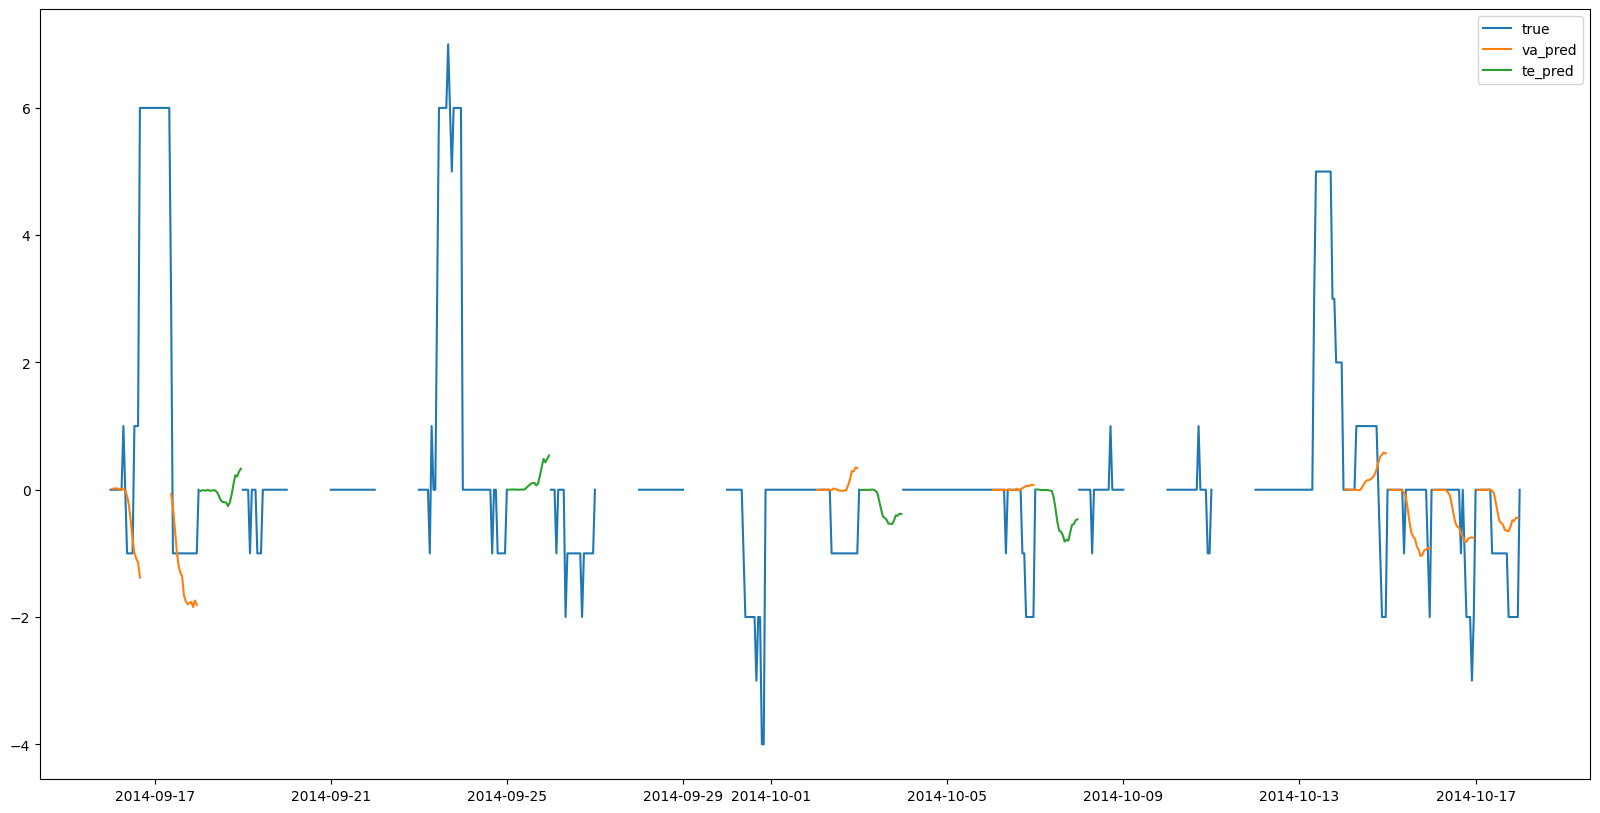

In [50]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# 需要＋供給＋介入

In [ ]:
def after_predict_process(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [ ]:
de_run_name = "lgbm_multiml_demand_202410142258"
de_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "va_pred.pkl"))
de_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "te_pred.pkl"))
de_va_te_pred = pd.concat([de_va_pred, de_te_pred], axis=0)
de_va_te_pred = de_va_te_pred.drop(columns=["target"])

In [ ]:
su_run_name = "lgbm_multiml_supply_202410151702"
su_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "va_pred.pkl"))
su_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "te_pred.pkl"))
su_va_te_pred = pd.concat([su_va_pred, su_te_pred], axis=0)
su_va_te_pred = su_va_te_pred.drop(columns=["target"])

In [ ]:
in_run_name = "lgbm_multiml_intervention_202410151853"
in_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "va_pred.pkl"))
in_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "te_pred.pkl"))
in_va_te_pred = pd.concat([in_va_pred, in_te_pred], axis=0)
in_va_te_pred = in_va_te_pred.drop(columns=["target"])

In [ ]:
df_predict_ = create_add_valid_dataset(df_predict)

In [ ]:
df_true_00 = df_target[df_target["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
df_true_00["date"] = df_true_00["datetime"].dt.date
df_true_00 = df_true_00.rename(columns={"bikes_available": "bikes_available_00"})
df_true_00 = df_true_00[["station_id", "date", "bikes_available_00"]]
df_pred = df_key.copy()
df_pred["date"] = df_pred["datetime"].dt.date
df_pred = pd.merge(df_pred, df_true_00, on=["station_id", "date"], how="left")
df_pred = df_pred[["station_id", "datetime", "bikes_available_00"]]

df_pred = df_pred.copy()
df_pred = pd.merge(df_pred, df_predict_, on=["station_id","datetime"], how="left")
df_pred = pd.merge(df_pred, de_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_de_va_pred"))
df_pred = pd.merge(df_pred, su_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_su_va_pred"))
df_pred = pd.merge(df_pred, in_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_in_va_pred"))

df_true = df_target[["station_id", "datetime", "bikes_available"]].copy()
df_true = pd.merge(df_true, df_predict_, on=["station_id", "datetime"], how="left")

In [ ]:
df_pred["bikes_available"] = df_pred["bikes_available_00"] + df_pred["demand_cumsum"] + df_pred["supply_cumsum"] + df_pred["intervention_cumsum"]

In [ ]:
df_metric = pd.merge(df_true, df_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_pred"))
df_metric = df_metric.dropna(subset=["bikes_available", "bikes_available_pred"])
df_metric = df_metric[df_metric["predict"]==2]
df_metric = df_metric.sort_values(["station_id", "datetime"])

In [ ]:
from sklearn.metrics import mean_absolute_error
def metric(va_true, va_pred):
    """評価指標の計算
    """
    score = mean_absolute_error(va_true, va_pred)
    # score = math.sqrt(mean_squared_error(va_true, va_pred))

    return score

metric(df_metric["bikes_available"].values,
       df_metric["bikes_available_pred"].values)

1.876879464472673

# LGBM_需要＋供給＋介入

In [89]:
df_main_ans = load_feature(os.path.join("df_key"))
df_main_ans = pd.merge(df_main_ans, load_feature("df_bikes_available_fillna"), on=["station_id","datetime"], how="left")
df_main_ans = pd.merge(df_main_ans, load_feature("df_predict_add_valid_flag"), on=["station_id","datetime"], how="left")
df_main_ans = pd.merge(df_main_ans, pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_demand_lstm.pkl")), on=["station_id","datetime"], how="left", suffixes=('', '_'))
df_main_ans = pd.merge(df_main_ans, pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_supply_lstm.pkl")) , on=["station_id","datetime"], how="left", suffixes=('', '_'))
df_main_ans = pd.merge(df_main_ans, pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_intervention_lstm.pkl")), on=["station_id","datetime"], how="left", suffixes=('', '_'))

In [104]:
import importlib
from src import runner
from src import model_LGBM
from src import model_ASMBL
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model_ASMBL)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention

In [91]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="ansamble_lgbm")
# run_name = 'ansamble_lgbm_202410190759'
run_name

'ansamble_lgbm_202410200546'

In [98]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # model run params
    "demand_model_cls": model_LSTM_mult,
    "supply_model_cls": model_LSTM_mult,
    "intervention_model_cls": model_LSTM_mult,
    "demand_run_name": "lstm_mult_demand_202410190321",
    "supply_run_name": "lstm_mult_supply_202410190339",
    "intervention_run_name": "lstm_mult_intervention_202410190357",
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [105]:
memo = "アンサンブルLGBM 特徴量追加"
ml_runner = MLModelRunner(
    run_name,
    model_ASMBL_demand_supply_intervention,
    model_params_lgb,
    df_main_ans,
    run_setting,
    cv_setting,
    logger,
    memo)

In [ ]:
ml_runner.run_train_cv()

[2024-10-20 06:02:20] - ansamble_lgbm_202410200546 - start training cv
INFO:../logs/general:[2024-10-20 06:02:20] - ansamble_lgbm_202410200546 - start training cv
[2024-10-20 06:02:20] - ansamble_lgbm_202410200546 fold 2014-09-01 - start training
INFO:../logs/general:[2024-10-20 06:02:20] - ansamble_lgbm_202410200546 fold 2014-09-01 - start training


(581210, 3)
(581210, 3)
(581210, 3)
(560694, 25)
(510784, 23) (510784,) (49910, 23) (49910,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1384
[LightGBM] [Info] Number of data points in the train set: 510784, number of used features: 23
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.92041	eval's l1: 2.06534
[200]	train's l1: 1.64398	eval's l1: 1.75631
[300]	train's l1: 1.55016	eval's l1: 1.63469
[400]	train's l1: 1.49573	eval's l1: 1.56735
[500]	train's l1: 1.46472	eval's l1: 1.53387
[600]	train's l1: 1.44772	eval's l1: 1.51793
[700]	train's l1: 1.44459	eval's l1: 1.51361
[800]	train's l1: 1.44175	eval's l1: 1.50942
[900]	train's l1: 1.44059	eval's l1: 1.5077
[1000]	train's l1: 1.44032	eval's 

[2024-10-20 06:08:59] - ansamble_lgbm_202410200546 fold 2014-09-01 - end training
INFO:../logs/general:[2024-10-20 06:08:59] - ansamble_lgbm_202410200546 fold 2014-09-01 - end training
[2024-10-20 06:08:59] - ansamble_lgbm_202410200546 fold 2014-10-01 - start training
INFO:../logs/general:[2024-10-20 06:08:59] - ansamble_lgbm_202410200546 fold 2014-10-01 - start training


(629510, 3)
(629510, 3)
(629510, 3)
(578404, 25)
(560694, 23) (560694,) (17710, 23) (17710,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.225165 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1389
[LightGBM] [Info] Number of data points in the train set: 560694, number of used features: 23
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.932	eval's l1: 4.89122
[200]	train's l1: 1.66853	eval's l1: 4.81198
[300]	train's l1: 1.57166	eval's l1: 4.74899
[400]	train's l1: 1.52221	eval's l1: 4.72097
[500]	train's l1: 1.49038	eval's l1: 4.70436
[600]	train's l1: 1.47688	eval's l1: 4.69722
[700]	train's l1: 1.47123	eval's l1: 4.69654
Early stopping, best iteration is:
[664]	train's l1: 1.4726	eval's l1: 4.69607


[2024-10-20 06:15:48] - ansamble_lgbm_202410200546 fold 2014-10-01 - end training
INFO:../logs/general:[2024-10-20 06:15:48] - ansamble_lgbm_202410200546 fold 2014-10-01 - end training
[2024-10-20 06:15:48] - ansamble_lgbm_202410200546 fold 2014-11-01 - start training
INFO:../logs/general:[2024-10-20 06:15:48] - ansamble_lgbm_202410200546 fold 2014-11-01 - start training


...

(872620, 3)
(872620, 3)
(872620, 3)
(660514, 25)
(647634, 23) (647634,) (12880, 23) (12880,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020883 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1394
[LightGBM] [Info] Number of data points in the train set: 647634, number of used features: 23
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 2.28968	eval's l1: 5.35241
[200]	train's l1: 1.98027	eval's l1: 4.92647
[300]	train's l1: 1.81536	eval's l1: 4.56145
[400]	train's l1: 1.71256	eval's l1: 4.41507
[500]	train's l1: 1.62913	eval's l1: 4.15788
[600]	train's l1: 1.60899	eval's l1: 4.14042
[700]	train's l1: 1.60227	eval's l1: 4.1323
[800]	train's l1: 1.59894	eval's l1: 4.11813
[900]	train's l1: 1.59644	eval's l1: 4.09547
[1000]	train's l1: 1.58882	eval's 

[2024-10-20 07:02:40] - ansamble_lgbm_202410200546 fold 2015-03-01 - end training
INFO:../logs/general:[2024-10-20 07:02:40] - ansamble_lgbm_202410200546 fold 2015-03-01 - end training
[2024-10-20 07:02:40] - ansamble_lgbm_202410200546 fold 2015-04-01 - start training
INFO:../logs/general:[2024-10-20 07:02:40] - ansamble_lgbm_202410200546 fold 2015-04-01 - start training


(922530, 3)
(922530, 3)
(922530, 3)
(676614, 25)
(660514, 23) (660514,) (16100, 23) (16100,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015948 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1393
[LightGBM] [Info] Number of data points in the train set: 660514, number of used features: 23
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 2.26768	eval's l1: 4.68529
[200]	train's l1: 1.95506	eval's l1: 4.22912
[300]	train's l1: 1.81526	eval's l1: 4.01616
[400]	train's l1: 1.73083	eval's l1: 4.0389
Early stopping, best iteration is:
[301]	train's l1: 1.81416	eval's l1: 4.01542


[2024-10-20 07:14:43] - ansamble_lgbm_202410200546 fold 2015-04-01 - end training
INFO:../logs/general:[2024-10-20 07:14:43] - ansamble_lgbm_202410200546 fold 2015-04-01 - end training
[2024-10-20 07:14:43] - ansamble_lgbm_202410200546 fold 2015-05-01 - start training
INFO:../logs/general:[2024-10-20 07:14:43] - ansamble_lgbm_202410200546 fold 2015-05-01 - start training


(970830, 3)


In [ ]:
# run_metric_cv
ans_model = ml_runner.build_model(i_fold)
ans_model.load_model()
demand_model, supply_model, intervention_model = ans_model._load_models()
demand_model_run_name = demand_model.run_fold_name.split("_fold")[0]
supply_model_run_name = supply_model.run_fold_name.split("_fold")[0]
intervention_model_run_name = intervention_model.run_fold_name.split("_fold")[0]
demand_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, demand_model_run_name, "va_pred.pkl"))
supply_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, supply_model_run_name, "va_pred.pkl"))
intervention_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, intervention_model_run_name, "va_pred.pkl"))
scores = []
preds = []
for i_fold in tqdm(ml_runner.get_cv_folds()):
    demand_va_pred_i_fold = demand_va_pred[(demand_va_pred['datetime'] >= i_fold)&(demand_va_pred['datetime'] < i_fold+pd.DateOffset(months=1))]
    supply_va_pred_i_fold = supply_va_pred[(supply_va_pred['datetime'] >= i_fold)&(supply_va_pred['datetime'] < i_fold+pd.DateOffset(months=1))]
    intervention_va_pred_i_fold = intervention_va_pred[(intervention_va_pred['datetime'] >= i_fold)&(intervention_va_pred['datetime'] < i_fold+pd.DateOffset(months=1))]

    # 予測値
    df_pred = demand_va_pred_i_fold.copy()
    df_pred = pd.merge(df_pred, supply_va_pred_i_fold, on=["station_id","datetime"], how="left")
    df_pred = pd.merge(df_pred, intervention_va_pred_i_fold, on=["station_id","datetime"], how="left")

    # 各レコードにその日の0時時点のデータを付与
    data_00 = df_main_ans[df_main_ans["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
    data_00["date"] = data_00["datetime"].dt.date
    data_00 = data_00.rename(columns={"bikes_available": "bikes_available_00"})
    data_00 = data_00[["station_id", "date", "bikes_available_00"]]
    df_pred["date"] = df_pred["datetime"].dt.date
    df_pred = pd.merge(df_pred, data_00, on=["station_id", "date"], how="left")
    df_pred = df_pred.drop(columns=["date"])

    # アンサンブル予測
    feat_cols = ans_model.model.feature_name()
    te_x = df_pred[feat_cols]
    pred = ans_model.model.predict(te_x, num_iteration=ans_model.model.best_iteration)
    df_pred[ans_model.target_col] = pred
    df_pred[ans_model.key_cols+[ans_model.target_col]].sort_values(ans_model.key_cols)

    self = ml_runner

    # 後処理
    df_pred = ml_runner.after_pred_func(df_pred, self.target_col)

    # 正解データの作成
    df_true = df_main_ans[df_main_ans["predict"]==2].copy()
    df_true = df_true[(df_true["datetime"] >= i_fold)&(df_true["datetime"] < i_fold+pd.DateOffset(months=1))]
    df_true = df_true[df_true["datetime"].dt.hour!=0][ans_model.key_cols + [ans_model.target_col]]

    # バリデーションデータの評価
    df_va_pred = df_pred.sort_values(self.key_cols)
    df_va_true = df_true.sort_values(self.key_cols)

    # 欠損値補完前の目的変数がNaNの行を削除
    target_data = pd.read_pickle(os.path.join(DIR_INTERIM, "df_target_all.pkl"))[self.key_cols + [self.target_col]]
    target_data = target_data.rename(columns={self.target_col: "target"})
    df_va_true = pd.merge(df_va_true, target_data, on=self.key_cols, how="inner")
    df_va_pred = pd.merge(df_va_pred, target_data, on=self.key_cols, how="inner")
    df_va_true = df_va_true.dropna(subset=["target"])
    df_va_pred = df_va_pred.dropna(subset=["target"])
    df_va_pred = df_va_pred.drop(columns=["target"])
    df_va_true = df_va_true.drop(columns=["target"])

    # score
    score = self.metric(df_va_true[self.target_col].values, df_va_pred[self.target_col].values)
    scores.append(score)
    preds.append(df_va_pred)

self = ml_runner

df_va_preds = pd.concat(preds, axis=0)

# 評価結果の保存
self.logger.info(f'{self.run_name} - start metric cv')
self.logger.result(f"memo: {self.memo}")
self.logger.result_scores(self.run_name, scores)
self.logger.result(f"mean: {np.mean(scores)}, std: {np.std(scores)}")
self.logger.info(f"mean: {np.mean(scores)}, std: {np.std(scores)}")
# 予測結果の保存
path_output = os.path.join(self.out_dir_name, f'va_pred.pkl')
Util.dump_df_pickle(df_va_preds, path_output)
self.logger.info(f'output predict : {path_output}')

self.logger.info(f'{self.run_name} - end metric cv')

In [ ]:
# run_predict_cv
ans_model = ml_runner.build_model(i_fold)
ans_model.load_model()
demand_model, supply_model, intervention_model = ans_model._load_models()
demand_model_run_name = demand_model.run_fold_name.split("_fold")[0]
supply_model_run_name = supply_model.run_fold_name.split("_fold")[0]
intervention_model_run_name = intervention_model.run_fold_name.split("_fold")[0]
demand_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, demand_model_run_name, "te_pred.pkl"))
supply_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, supply_model_run_name, "te_pred.pkl"))
intervention_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, intervention_model_run_name, "te_pred.pkl"))
preds = []
for i_fold in tqdm(ml_runner.get_cv_folds()):
    demand_va_pred_i_fold = demand_va_pred[(demand_va_pred['datetime'] >= i_fold)&(demand_va_pred['datetime'] < i_fold+pd.DateOffset(months=1))]
    supply_va_pred_i_fold = supply_va_pred[(supply_va_pred['datetime'] >= i_fold)&(supply_va_pred['datetime'] < i_fold+pd.DateOffset(months=1))]
    intervention_va_pred_i_fold = intervention_va_pred[(intervention_va_pred['datetime'] >= i_fold)&(intervention_va_pred['datetime'] < i_fold+pd.DateOffset(months=1))]

    # 予測値
    df_pred = demand_va_pred_i_fold.copy()
    df_pred = pd.merge(df_pred, supply_va_pred_i_fold, on=["station_id","datetime"], how="left")
    df_pred = pd.merge(df_pred, intervention_va_pred_i_fold, on=["station_id","datetime"], how="left")

    # 各レコードにその日の0時時点のデータを付与
    data_00 = df_main_ans[df_main_ans["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
    data_00["date"] = data_00["datetime"].dt.date
    data_00 = data_00.rename(columns={"bikes_available": "bikes_available_00"})
    data_00 = data_00[["station_id", "date", "bikes_available_00"]]
    df_pred["date"] = df_pred["datetime"].dt.date
    df_pred = pd.merge(df_pred, data_00, on=["station_id", "date"], how="left")
    df_pred = df_pred.drop(columns=["date"])

    # アンサンブル予測
    feat_cols = ans_model.model.feature_name()
    te_x = df_pred[feat_cols]
    pred = ans_model.model.predict(te_x, num_iteration=ans_model.model.best_iteration)
    df_pred[ans_model.target_col] = pred
    df_pred[ans_model.key_cols+[ans_model.target_col]].sort_values(ans_model.key_cols)

    self = ml_runner

    # 後処理
    df_pred = ml_runner.after_pred_func(df_pred, self.target_col)

    preds.append(df_pred)

self = ml_runner

df_te_preds = pd.concat(preds, axis=0)

# 予測結果の保存
self.logger.info(f'{self.run_name} - start prediction cv')
path_output = os.path.join(self.out_dir_name, f'te_pred.pkl')
Util.dump_df_pickle(df_te_preds, path_output)
self.logger.info(f'output predict : {path_output}')

self.logger.info(f'{self.run_name} - end prediction cv')

In [ ]:
ml_runner.plot_feature_importance_cv()

In [ ]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = load_feature("df_target_all")[ml_runner.key_cols+[ml_runner.target_col]]

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# Submissionの作成

In [ ]:
runner = ml_runner

In [ ]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [ ]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [ ]:
df_prep_station

,station_id,lat,long,dock_count,city,installation_date
0,0,37.32973,-121.90178,27,city1,2013-08-06
1,1,37.33070,-121.88898,15,city1,2013-08-05
2,2,37.33399,-121.89490,11,city1,2013-08-06
3,3,37.33141,-121.89320,19,city1,2013-08-05
4,4,37.33672,-121.89407,15,city1,2013-08-07
...,...,...,...,...,...,...
65,65,37.78963,-122.40081,27,city2,2013-08-25
66,66,37.35260,-121.90573,15,city1,2013-12-31
67,67,37.79854,-122.40086,15,city2,2014-01-22
68,68,37.49127,-122.23623,15,city3,2014-02-20


In [ ]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)
print(path_submit)

/Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/data/submission/lgbm_multimodel_202410132324_submit.csv


In [ ]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,14.999987
1,8762,15.000038
2,8763,14.999989
3,8764,14.993988
4,8765,14.965969
...,...,...
193195,1226347,9.725839
193196,1226348,9.529384
193197,1226349,10.058437
193198,1226350,10.155552


In [ ]:
pd.read_csv(path_submit, header=None).isnull().sum()

0    0
1    0
dtype: int64